# Install and Import Pandas & Matplotlib

In [11]:
pip install pandas #to install pandas
!pip install matplotlib #to install matplotlib
pip install seaborn #to install seaborn

# Import

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example with time series dataset

### 1. Import dataset

In [32]:
data = pd.read_csv("daily_sales.csv")

### 2.  Exploration EDA

dataset information...shape

In [15]:
data.head()

,date,sales,visitors,promo
0,2022-01-01,63.97,158,0
1,2022-01-02,70.71,187,0
2,2022-01-03,79.99,187,0
3,2022-01-04,78.99,195,0
4,2022-01-05,52.03,166,0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      1096 non-null   str    
 1   sales     1096 non-null   float64
 2   visitors  1096 non-null   int64  
 3   promo     1096 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 34.4 KB


There is an error in reading data!!

In [6]:
data.shape

(1096, 4)

descreptive statistics (each one or all)

In [7]:
#All variables
data.describe()

,sales,visitors,promo
count,1096.000000,1096.000000,1096.000000
mean,144.083832,395.720803,0.139599
std,40.524518,126.948178,0.346728
min,35.000000,94.000000,0.000000
25%,114.967500,303.750000,0.000000
50%,143.975000,389.000000,0.000000
75%,172.480000,481.250000,0.000000
max,234.770000,791.000000,1.000000


In [14]:
#sales
data["sales"].describe()

count    1096.000000
mean      144.083832
std        40.524518
min        35.000000
25%       114.967500
50%       143.975000
75%       172.480000
max       234.770000
Name: sales, dtype: float64

In [19]:
#sales & promo
des = data[["sales","promo"]].describe()

In [ ]:
#csv
des.to_csv("sales_promo_descreptive.csv")

In [23]:
des.to_excel("sales_promo_descreptive.xlsx")

In [22]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

Correct date type from str to datetime

In [33]:
data["date"] = pd.to_datetime(data["date"])

In [25]:
# to check if date type has been changed from str to datetime
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      1096 non-null   datetime64[us]
 1   sales     1096 non-null   float64       
 2   visitors  1096 non-null   int64         
 3   promo     1096 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 34.4 KB


Resampling

In [28]:
data.head()

,date,sales,visitors,promo
0,2022-01-01,63.97,158,0
1,2022-01-02,70.71,187,0
2,2022-01-03,79.99,187,0
3,2022-01-04,78.99,195,0
4,2022-01-05,52.03,166,0


In [34]:
# Set index from 0,1,2 to date
data1 = data.set_index("date")

In [35]:
#check
data1.head()

,sales,visitors,promo
date,,,
2022-01-01,63.97,158,0
2022-01-02,70.71,187,0
2022-01-03,79.99,187,0
2022-01-04,78.99,195,0
2022-01-05,52.03,166,0


<Axes: >

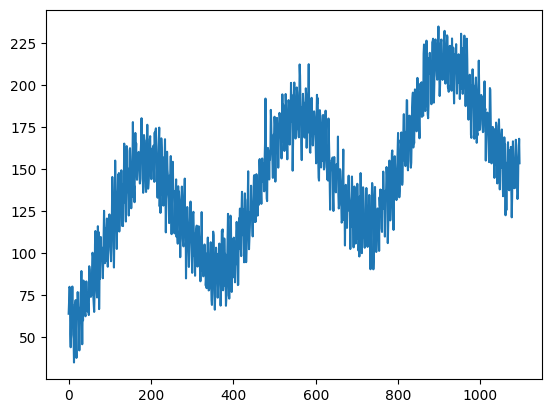

In [36]:
#to understanf the diff
data["sales"].plot()

<Axes: xlabel='date'>

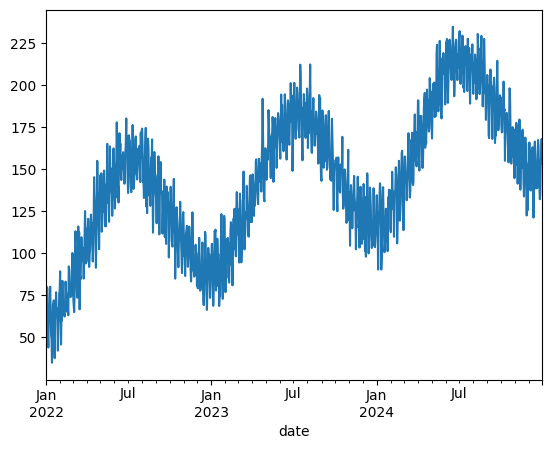

In [37]:
data1["sales"].plot()

In [44]:
#weekly = ('W')
weekly = data1.resample("W").mean()
monthly = data1.resample("ME").mean()
#quarterly = ('Q')

In [42]:
weekly.head()

,sales,visitors,promo
date,,,
2022-01-02,67.340000,172.500000,0.000000
2022-01-09,64.662857,172.285714,0.000000
2022-01-16,56.865714,162.142857,0.142857
2022-01-23,61.705714,186.000000,0.000000
2022-01-30,62.007143,175.142857,0.285714


In [46]:
monthly.head()
monthly.to_csv("monthly_sales.csv")

In [47]:
monthly.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 36 entries, 2022-01-31 to 2024-12-31
Freq: ME
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sales     36 non-null     float64
 1   visitors  36 non-null     float64
 2   promo     36 non-null     float64
dtypes: float64(3)
memory usage: 1.1 KB


In [50]:
Quarterly = data1.resample("QE").mean()

In [51]:
Quarterly.head()

,sales,visitors,promo
date,,,
2022-03-31,76.854111,212.111111,0.133333
2022-06-30,135.892527,368.681319,0.153846
2022-09-30,144.152935,403.717391,0.097826
2022-12-31,101.177500,273.815217,0.097826
2023-03-31,106.858556,294.944444,0.155556


In [52]:
#Yearly
yearly = data1.resample("YE").mean()

In [53]:
yearly.head()

,sales,visitors,promo
date,,,
2022-12-31,114.667096,314.994521,0.120548
2023-12-31,143.515562,395.150685,0.136986
2024-12-31,173.986913,476.795082,0.161202


### 3. Iloc()

In [54]:
data1.head()

,sales,visitors,promo
date,,,
2022-01-01,63.97,158,0
2022-01-02,70.71,187,0
2022-01-03,79.99,187,0
2022-01-04,78.99,195,0
2022-01-05,52.03,166,0


In [55]:
data1.tail()

,sales,visitors,promo
date,,,
2024-12-27,135.39,457,0
2024-12-28,153.26,445,1
2024-12-29,159.63,442,0
2024-12-30,168.02,498,0
2024-12-31,153.47,534,0


<Axes: xlabel='date'>

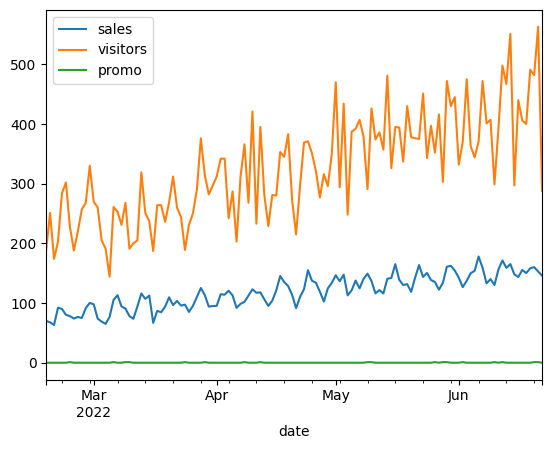

In [65]:
#2022-02-17 --- 2022-06-22  performance (plot) loc and iloc
data1.loc["2022-02-17":"2022-06-22"].plot()

In [66]:
#2023-05-05.....2023-05-13
data1.loc["2023-05-05":"2023-05-13"]

,sales,visitors,promo
date,,,
2023-05-05,155.63,321,0
2023-05-06,160.90,413,0
2023-05-07,185.18,632,0
2023-05-08,177.50,605,0
2023-05-09,162.52,416,0
2023-05-10,169.21,466,0
2023-05-11,153.85,470,0
2023-05-12,144.76,503,1
2023-05-13,163.87,521,0


In [68]:
#2023-05-05.....2023-05-13 hourly
data1.loc["2023-05-05":"2023-05-13"].resample("h").mean()

,sales,visitors,promo
date,,,
2023-05-05 00:00:00,155.63,321.0,0.0
2023-05-05 01:00:00,NaN,NaN,NaN
2023-05-05 02:00:00,NaN,NaN,NaN
2023-05-05 03:00:00,NaN,NaN,NaN
2023-05-05 04:00:00,NaN,NaN,NaN
...,...,...,...
2023-05-12 20:00:00,NaN,NaN,NaN
2023-05-12 21:00:00,NaN,NaN,NaN
2023-05-12 22:00:00,NaN,NaN,NaN


### 4. Plot with Kind and its arguments & Heatmap

**data.plot(title = "...", xlabel = "....", ylabel = "...", kind = "...)**

In [ ]:
#line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')

<Axes: title={'center': 'Plot of sales and visitors'}, xlabel='Days', ylabel='Values'>

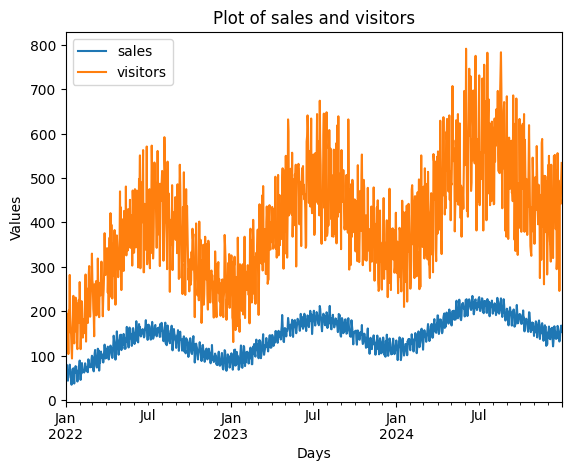

In [82]:
#plot
data1[["sales", "visitors"]].plot(title = "Plot of sales and visitors", xlabel = "Days", ylabel = "Values", kind= "line")

<Axes: title={'center': 'Histogram of sales and visitors'}, xlabel='Days', ylabel='Values'>

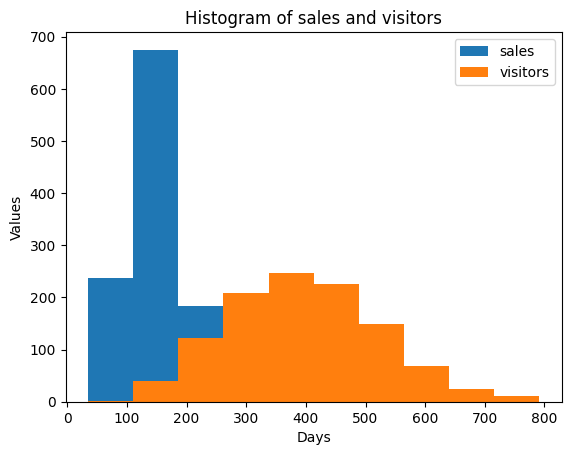

In [78]:
#Histogram
data1[["sales", "visitors"]].plot(title = "Histogram of sales and visitors", xlabel = "Days", ylabel = "Values", kind= "hist")

<Axes: title={'center': 'Boxplot of sales and visitors'}, xlabel='Days', ylabel='Values'>

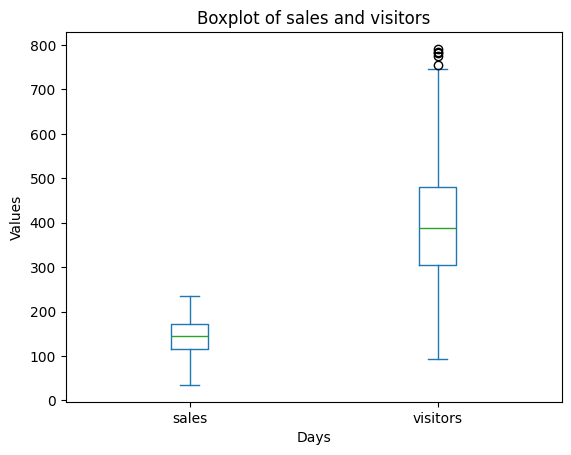

In [80]:
#Boxplot
data1[["sales", "visitors"]].plot(title = "Boxplot of sales and visitors", xlabel = "Days", ylabel = "Values", kind= "box")

In [83]:
pip install scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Note: you may need to restart the kernel to use updated packages.


<Axes: title={'center': 'Distribution of sales and visitors'}, ylabel='Density'>

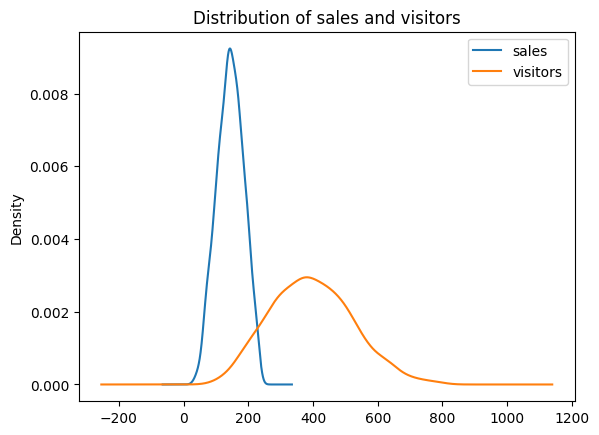

In [84]:
#dist kde
data1[["sales", "visitors"]].plot(title = "Distribution of sales and visitors", xlabel = "Days", ylabel = "Values", kind= "kde")

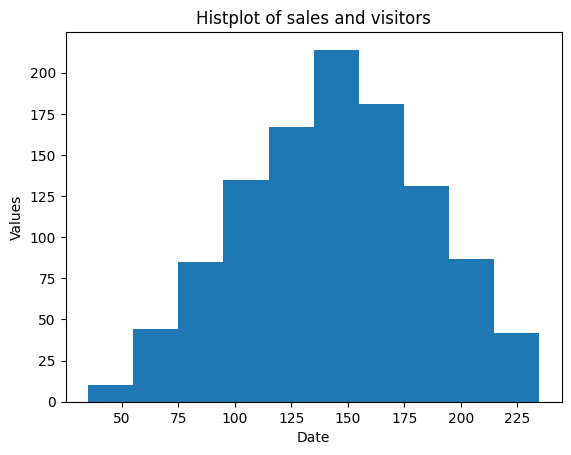

<Axes: title={'center': 'Histplot of sales and visitors'}, ylabel='Density'>

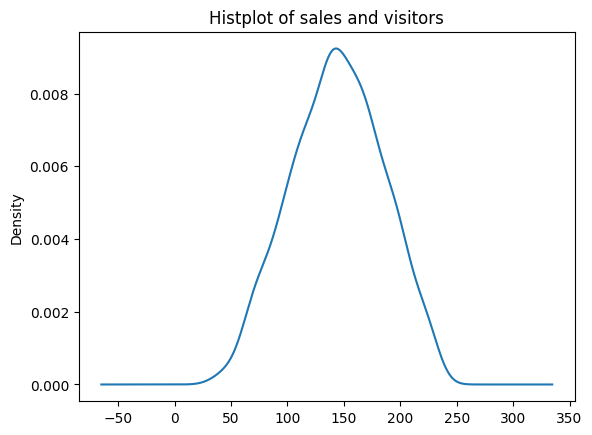

In [95]:
#hist plot
data1["sales"].plot(title = "Histplot of sales and visitors", xlabel = "Date", ylabel = "Values", kind = "hist")
plt.show()
data1["sales"].plot(title = "Histplot of sales and visitors", xlabel = "Date", ylabel = "Values", kind = "kde")

<Axes: xlabel='sales', ylabel='visitors'>

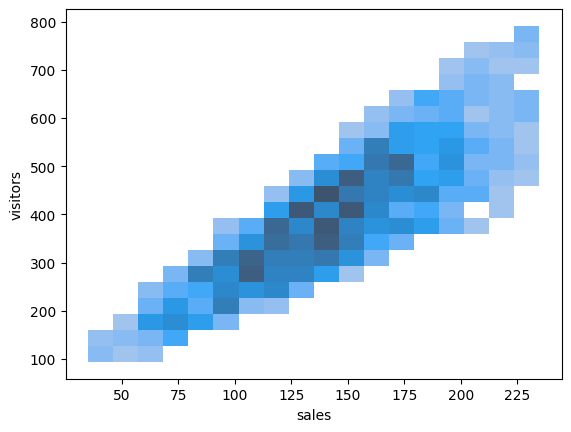

In [99]:
#hsitplot sales
sns.histplot(data = data1, x = "sales", y="visitors")

Task : distribution of visitors and sales from 2023-06-01 to 2024-06-01.....understand figsize .....and download figures

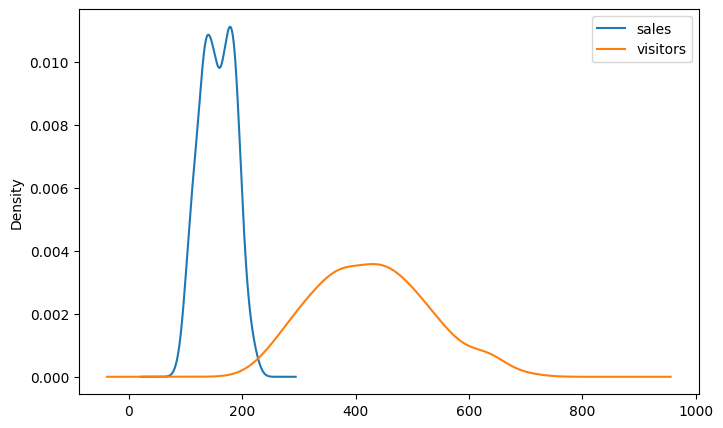

In [108]:
data1[["sales","visitors"]].loc["2023-06-01":"2024-06-01"].plot(kind = "kde", figsize = (8,5))
plt.savefig("distribution.png") #pdf
plt.show()

---

# Example with Cross Sectional data 

In [109]:
med = pd.read_csv("medical_data.csv")

In [110]:
med.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           500 non-null    int64  
 1   sex                  500 non-null    str    
 2   age                  500 non-null    int64  
 3   height_cm            500 non-null    float64
 4   weight_kg            500 non-null    float64
 5   bmi                  500 non-null    float64
 6   systolic_bp          500 non-null    int64  
 7   diastolic_bp         500 non-null    int64  
 8   cholesterol          500 non-null    float64
 9   glucose              500 non-null    float64
 10  smoker               500 non-null    str    
 11  exercise_hours_week  500 non-null    float64
 12  diabetic             500 non-null    int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 50.9 KB


rename columns

In [113]:
med.rename(columns = {"patient_id": "id",
                      "sex" : "gender",
                      "age" : "age",
                      "height_cm" : "height_cm",
                      "weight_kg" : "weight_kg",
                      "bmi" : "BMI",
                      "systolic_bp" : "systolic_bp",
                      "diastolic_bp" : "diastolic_bp",
                      "cholesterol" : "cholesterol",
                      "glucose" : "glu",
                      "exercise_hours_week" : "sport",
                      "diabetic" : "diabetic",
                     "smoker" : "smoker"}, inplace = True)

In [114]:
med.head()

,id,gender,age,height_cm,weight_kg,BMI,systolic_bp,diastolic_bp,cholesterol,glu,smoker,sport,diabetic
0,1,Female,37,167.4,70.0,24.98,140,80,193.5,107.4,No,2.3,0
1,2,Male,56,169.9,82.5,28.58,148,75,199.9,109.9,No,3.4,1
2,3,Female,56,167.3,50.7,18.11,126,91,190.2,95.7,No,3.0,1
3,4,Female,30,177.4,65.7,20.88,130,83,168.6,107.8,No,1.0,0
4,5,Female,58,176.1,73.6,23.73,124,72,197.3,89.3,Yes,4.3,1


subplots

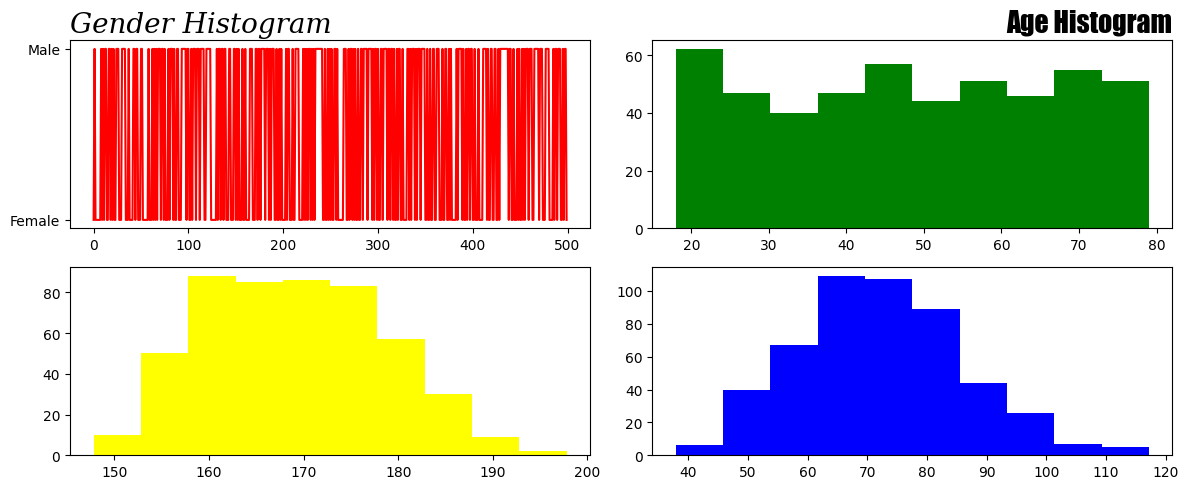

In [150]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (12, 5))
font = {"family":"serif", "style":"italic","size":20}
font1 = {"family":"fantasy", "style":"italic","size":20}
ax1.plot(med["gender"], color = "red")
ax1.set_title("Gender Histogram", font, loc = "left")
ax2.hist(med["age"], color = "green")
ax2.set_title("Age Histogram", font1, loc = "right")
ax3.hist(med["height_cm"], color = "yellow")
ax4.hist(med["weight_kg"], color = "blue")
plt.tight_layout()
plt.show()

Subplots Distribution for MED

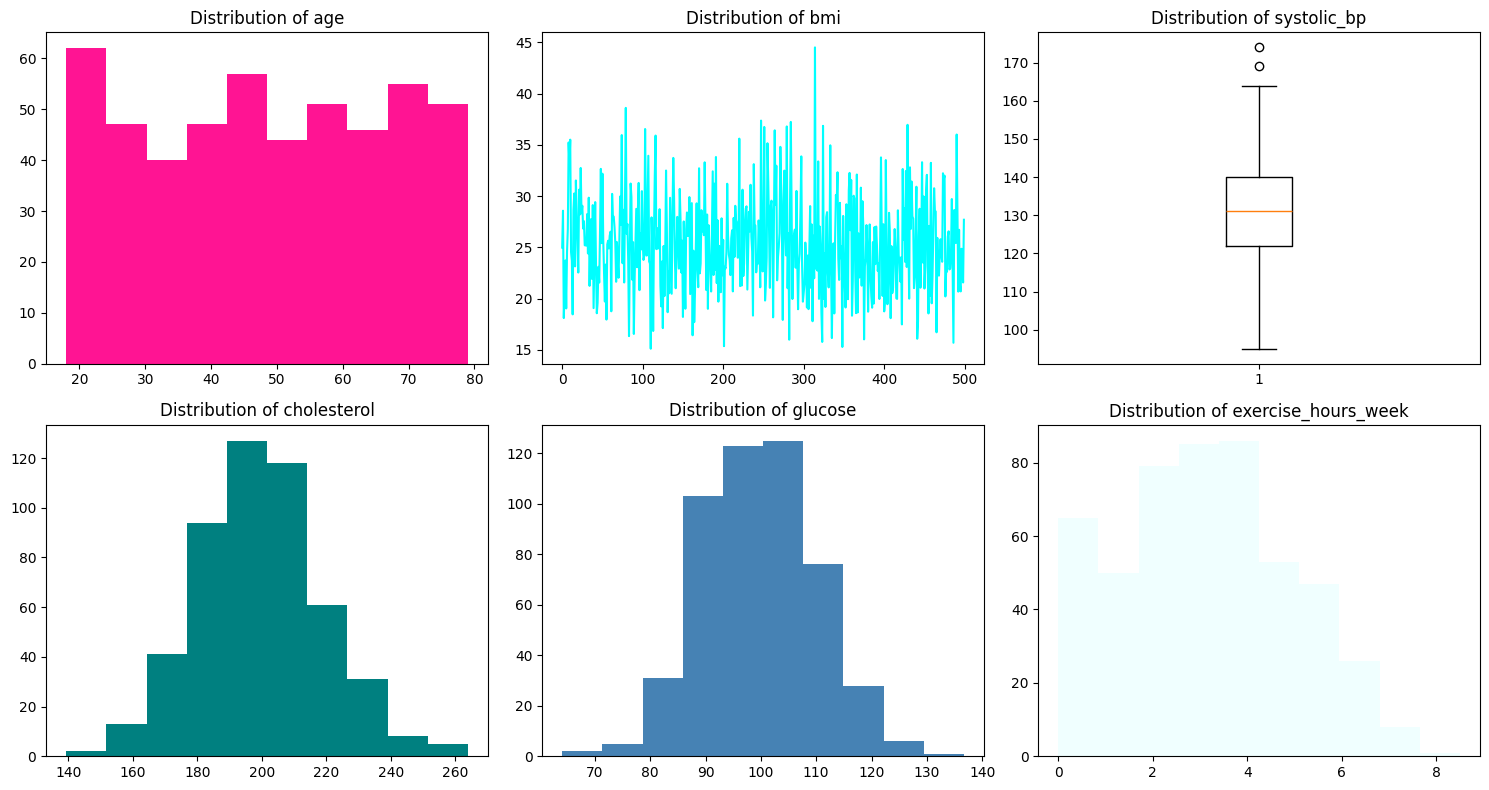

In [161]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 8))

ax1.hist(med['age'], color='deeppink')
ax1.set_title('Distribution of age')

ax2.plot(med['BMI'], color='aqua')
ax2.set_title('Distribution of bmi')

ax3.boxplot(med['systolic_bp'])
ax3.set_title('Distribution of systolic_bp')

ax4.hist(med['cholesterol'], color='teal')
ax4.set_title('Distribution of cholesterol')

ax5.hist(med['glu'], color='steelblue')
ax5.set_title('Distribution of glucose')

ax6.hist(med['sport'], color='azure')
ax6.set_title('Distribution of exercise_hours_week')

plt.tight_layout()
plt.savefig("hist_six_var.png")
plt.show()

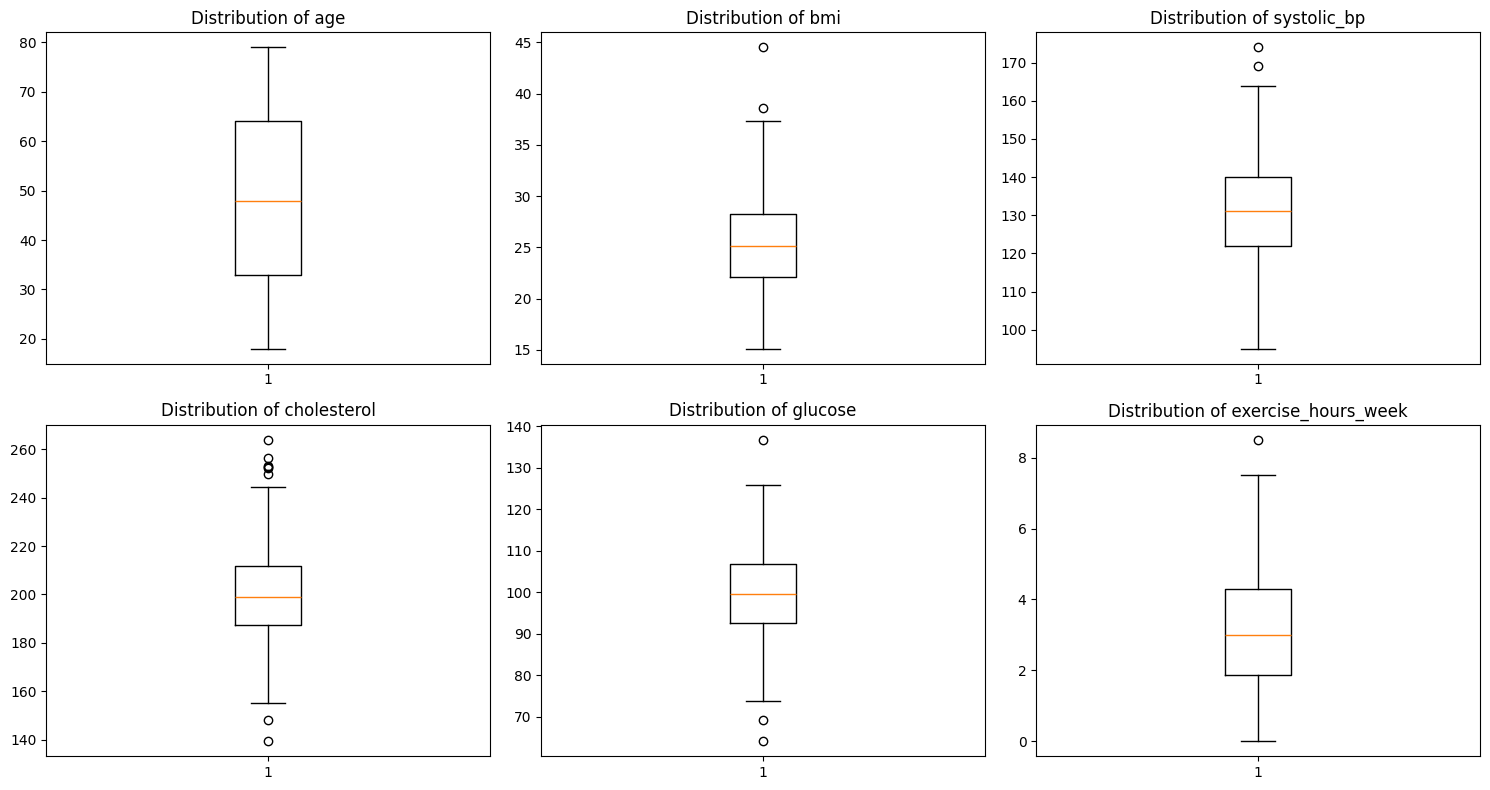

In [162]:
import matplotlib.pyplot as plt

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 8))

ax1.boxplot(med['age'])
ax1.set_title('Distribution of age')

ax2.boxplot(med['BMI'])
ax2.set_title('Distribution of bmi')

ax3.boxplot(med['systolic_bp'])
ax3.set_title('Distribution of systolic_bp')

ax4.boxplot(med['cholesterol'])
ax4.set_title('Distribution of cholesterol')

ax5.boxplot(med['glu'])
ax5.set_title('Distribution of glucose')

ax6.boxplot(med['sport'])
ax6.set_title('Distribution of exercise_hours_week')

plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

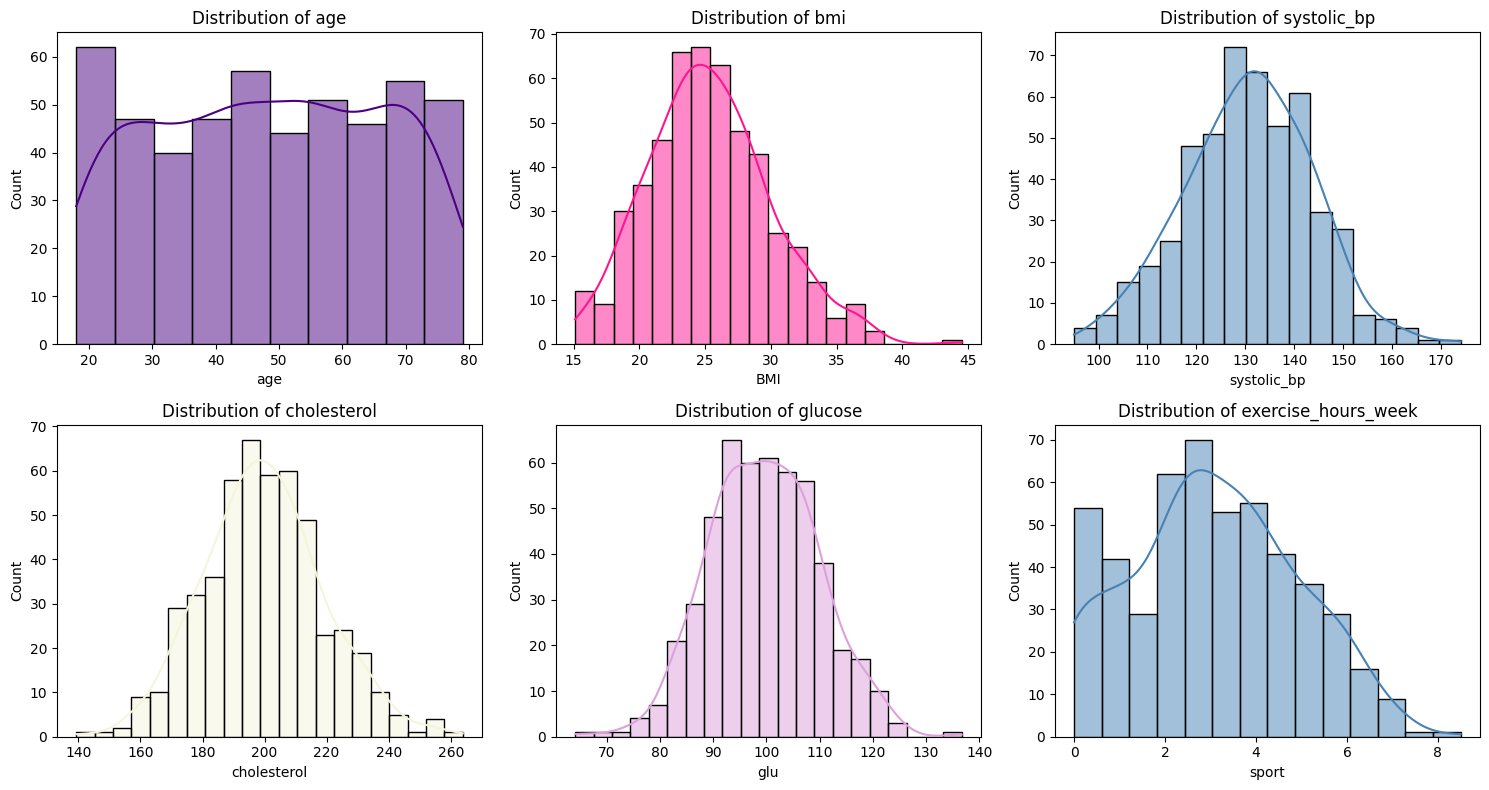

In [166]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(med['age'], kde=True, ax=ax1, color='indigo')
ax1.set_title('Distribution of age')

sns.histplot(med['BMI'], kde=True, ax=ax2, color='deeppink')
ax2.set_title('Distribution of bmi')

sns.histplot(med['systolic_bp'], kde=True, ax=ax3, color='steelblue')
ax3.set_title('Distribution of systolic_bp')

sns.histplot(med['cholesterol'], kde=True, ax=ax4, color='beige')
ax4.set_title('Distribution of cholesterol')

sns.histplot(med['glu'], kde=True, ax=ax5, color='plum')
ax5.set_title('Distribution of glucose')

sns.histplot(med['sport'], kde=True, ax=ax6, color='steelblue')
ax6.set_title('Distribution of exercise_hours_week')

plt.tight_layout()
plt.savefig("plots_sns.png")
plt.show()

Categorical Breakdown

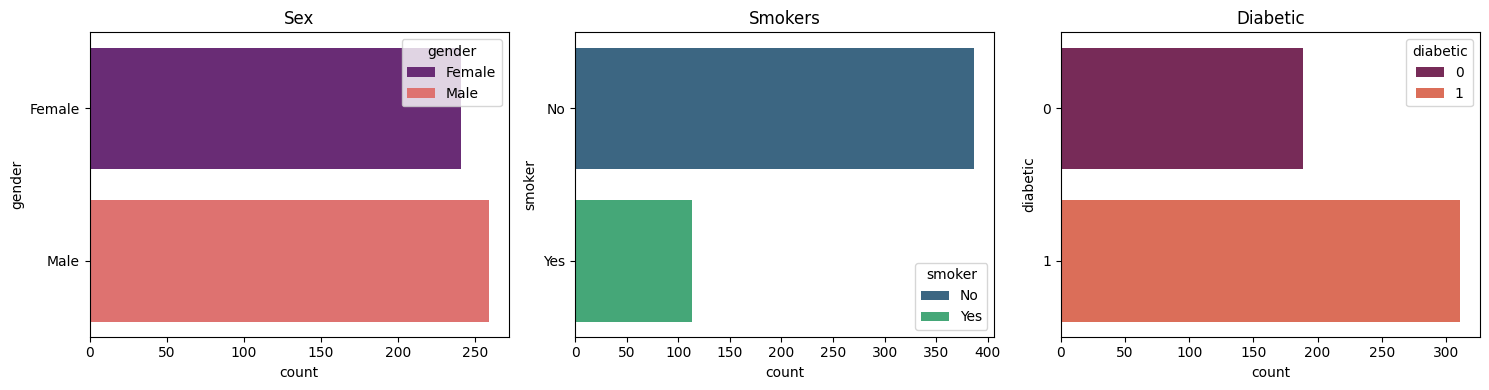

In [182]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

#Sex Count Plot
sns.countplot(data=med, y='gender', ax=ax1, hue='gender', palette='magma', legend=True)
ax1.set_title('Sex')

#Smokers Count Plot
sns.countplot(data=med, y='smoker', ax=ax2, hue='smoker', palette='viridis', legend=True)
ax2.set_title('Smokers')

#Diabetic Count Plot
sns.countplot(data=med, y='diabetic', ax=ax3, hue='diabetic', palette='rocket', legend=True)
ax3.set_title('Diabetic')

plt.tight_layout()
plt.savefig("categorical.png")
plt.show()

Sex & Diabetic

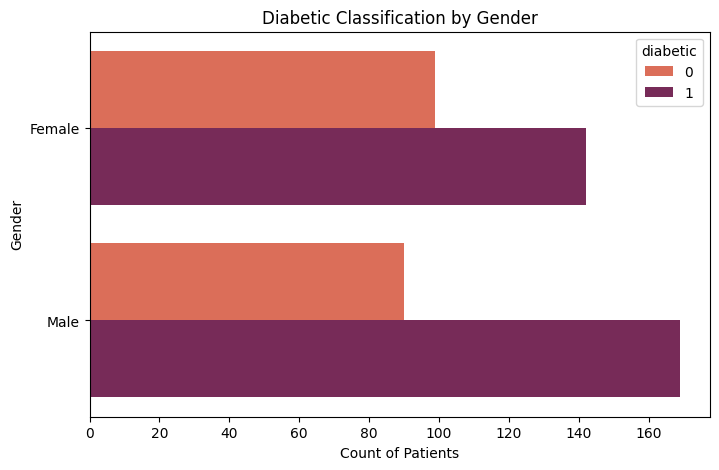

In [184]:
plt.figure(figsize=(8, 5))

sns.countplot(data=med, y='gender', hue='diabetic', palette='rocket_r')

plt.title('Diabetic Classification by Gender')
plt.ylabel('Gender')
plt.xlabel('Count of Patients')

plt.show()

Box plots — clinical variables by sex

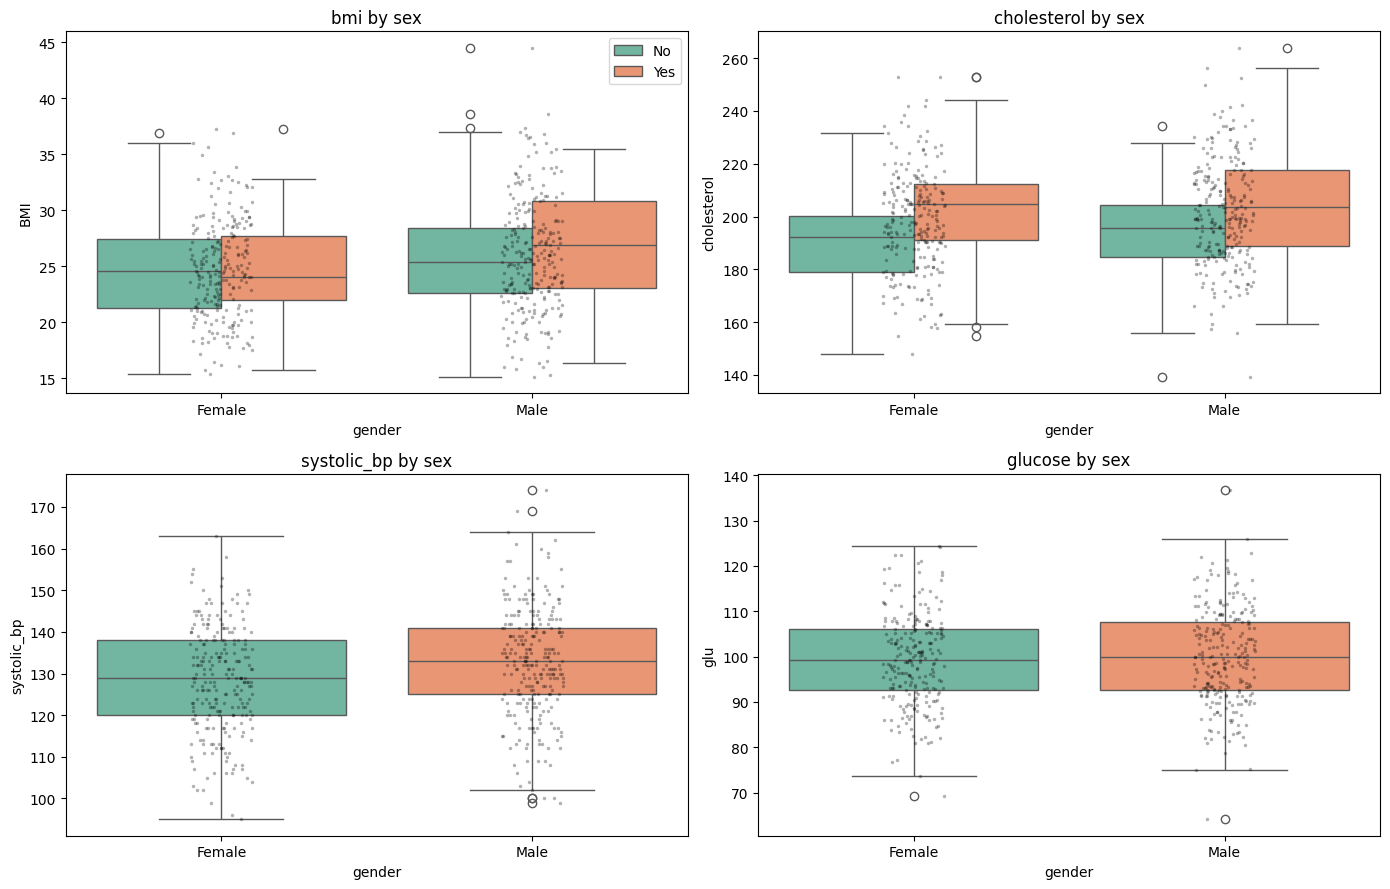

In [190]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=med, x='gender', y='BMI', ax=ax1, hue='smoker', palette='Set2', legend=True)
sns.stripplot(data=med, x='gender', y='BMI', ax=ax1, color='black', alpha=0.3, size=2.5)
ax1.set_title('bmi by sex')

sns.boxplot(data=med, x='gender', y='cholesterol', ax=ax2, hue='diabetic', palette='Set2', legend=False)
sns.stripplot(data=med, x='gender', y='cholesterol', ax=ax2, color='black', alpha=0.3, size=2.5)
ax2.set_title('cholesterol by sex')

sns.boxplot(data=med, x='gender', y='systolic_bp', ax=ax3, hue='gender', palette='Set2', legend=False)
sns.stripplot(data=med, x='gender', y='systolic_bp', ax=ax3, color='black', alpha=0.3, size=2.5)
ax3.set_title('systolic_bp by sex')

sns.boxplot(data=med, x='gender', y='glu', ax=ax4, hue='gender', palette='Set2', legend=False)
sns.stripplot(data=med, x='gender', y='glu', ax=ax4, color='black', alpha=0.3, size=2.5)
ax4.set_title('glucose by sex')

plt.tight_layout()
plt.show()

Violin — glucose by smoker / diabetic

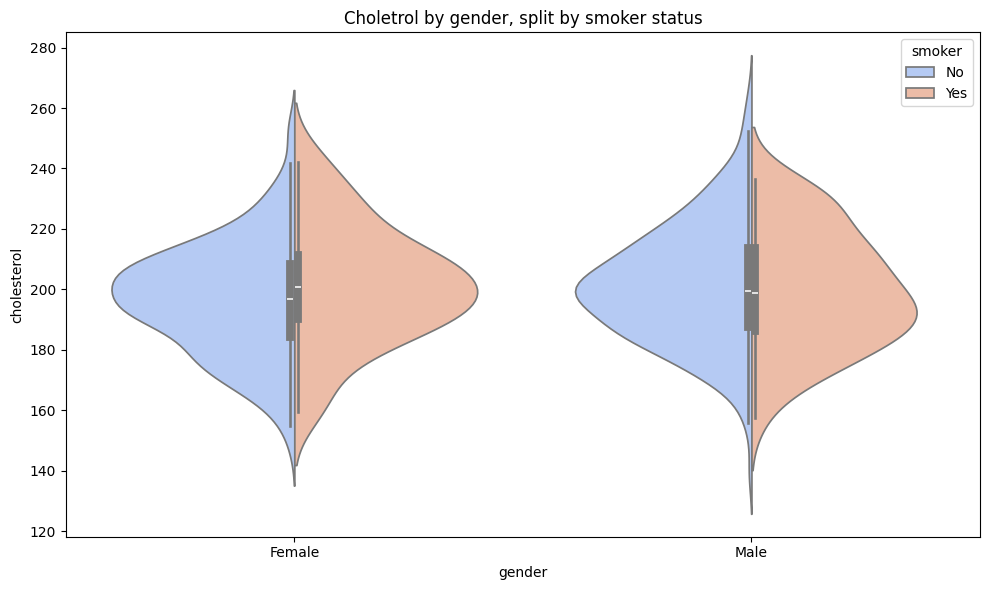

In [193]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=med, x='gender', y='cholesterol', hue='smoker', split=True, palette='coolwarm')
plt.title('Choletrol by gender, split by smoker status')
plt.tight_layout()
plt.show()

GroupBy

In [194]:
by_sex = med.groupby("gender")[["age","BMI","cholesterol","glu","systolic_bp"]].mean().reset_index()
print(by_sex)

   gender        age        BMI  cholesterol        glu  systolic_bp
0  Female  47.630705  24.741328   197.963071  99.296680   128.315353
1    Male  48.861004  25.907066   201.188417  99.979151   132.749035


In [196]:
#groupby smoker
by_smoking = med.groupby("smoker")[["age", "glu"]].mean()
print(by_smoking)

              age        glu
smoker                      
No      48.129199  99.790181
Yes     48.743363  99.170796


Create Datasets for research

In [201]:
#only male 
male_dataset = med[(med["gender"] == "Male")]
male_dataset.to_csv("Male.csv")

In [200]:
male_dataset.head()

,id,gender,age,height_cm,weight_kg,BMI,systolic_bp,diastolic_bp,cholesterol,glu,smoker,sport,diabetic
1,2,Male,56,169.9,82.5,28.58,148,75,199.9,109.9,No,3.4,1
8,9,Male,29,168.7,100.3,35.24,127,80,204.7,97.2,No,4.0,1
10,11,Male,73,163.3,94.7,35.51,125,87,234.1,100.6,Yes,5.8,1
12,13,Male,50,178.6,75.6,23.70,134,85,214.8,107.0,No,2.7,1
13,14,Male,74,180.1,59.9,18.47,139,81,216.2,110.2,Yes,3.7,1


In [203]:
female_dataset = med[med["gender"] == "Female"]
female_dataset.to_csv("female.csv")

In [205]:
male_smoker = med[(med["gender"] == "Male") & (med["smoker"] == "Yes")]
male_smoker.to_csv("male_smoker.csv")

In [210]:
female_smoker_diabetic = med[(med["gender"] == "Female") & (med["smoker"] == "Yes") & (med["diabetic"] == 1) & (med["age"] > 25)]
female_smoker_diabetic.to_csv("fsd_age.csv")

# Merge datasets

In [212]:
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv', parse_dates=['order_date']) # parse to read date as date not str
loyalty = pd.read_csv('loyalty.csv')

Merge on `customer_id`

In [216]:
step1 = pd.merge(customers, orders, on='customer_id', how='inner')
step1.to_csv("customers_orders.csv")

In [217]:
merged = pd.merge(step1, loyalty, on='customer_id', how='left')
merged.to_csv("merged.csv")

Filter only who have ordered an amount more than 200

In [218]:
amount_300 = merged[merged["amount"] > 300]

In [219]:
amount_300.to_csv("amount_300.csv")

---